In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from xgboost import XGBClassifier

LOADING THE DATASET

In [47]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

data = pd.read_csv(
    url,
    sep=';',
    header=None
)

print(data.shape)

(1055, 42)


FEATURES & LABELS

In [48]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

TRAIN/TEST SPLIT

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, 
    random_state=42,
    stratify=y
)

XGBOOST MODEL

In [50]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4, 
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

TRAINING & PREDICTION

In [51]:
# Train
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

ACCURACY

In [52]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8720379146919431


CONFUSION MATRIX & CLASSIFICATION REPORT

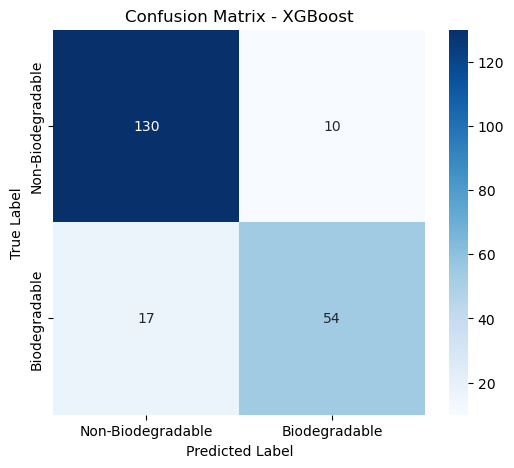


Classification Report

                   precision    recall  f1-score   support

Non-Biodegradable     0.8844    0.9286    0.9059       140
    Biodegradable     0.8438    0.7606    0.8000        71

         accuracy                         0.8720       211
        macro avg     0.8641    0.8446    0.8530       211
     weighted avg     0.8707    0.8720    0.8703       211



In [53]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Biodegradable', 'Biodegradable'],
    yticklabels=['Non-Biodegradable', 'Biodegradable']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost')
plt.show()


print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Non-Biodegradable', 'Biodegradable'],
        digits=4
    )
)

ROC CURVE

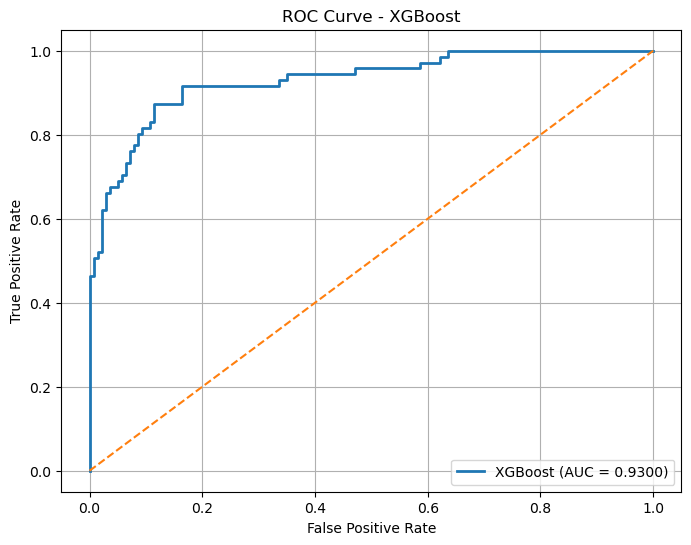

In [54]:

# Predicted probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2,
         label=f'XGBoost (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()